In [1]:
import pandas as pd

# Read the Excel file
df = pd.read_excel('DB.xlsx')

In [2]:
df.drop(columns=['ID', 'EDAD', 'EDAD_2CAT', 'TIPO_HIST', 'TAMAÑO', 'TAM2CAT', 'GDIF', 'GDIF2CAT', 'FENOTIPO', 'LUM_NO_LUM', 'KI67', 'KI67_3CAT', 'KI67_2CAT', 'NECR', 'INVA', 'GANGLIOS', 'TILS', 'TILS2CAT', 'RECIDIVA', 'SLE', 'SIT_ACTUAL', 'SG', 'filter_$', 'Fenotipo_3CAT', 'SCF_2CAT_OS', 'GDIF_IyII_III', 'Galectin9_2cat_OS', 'MCP1_2cat_OS', 'IL2RA_2cat_OS', 'B7_2_2cat_OS', 'B7_2_2cat_DFS', 'PD1_2cat_DFS'], inplace=True)

In [3]:
# Basic cleaning: ensure numeric values and handle commas
for col in df.columns:
    # replace comma decimal separators with dot
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='ignore')

print("After cleaning, shape:", df.shape)


After cleaning, shape: (279, 62)


Heatmap 1 created: 50 healthy patients and 229 tumor patients


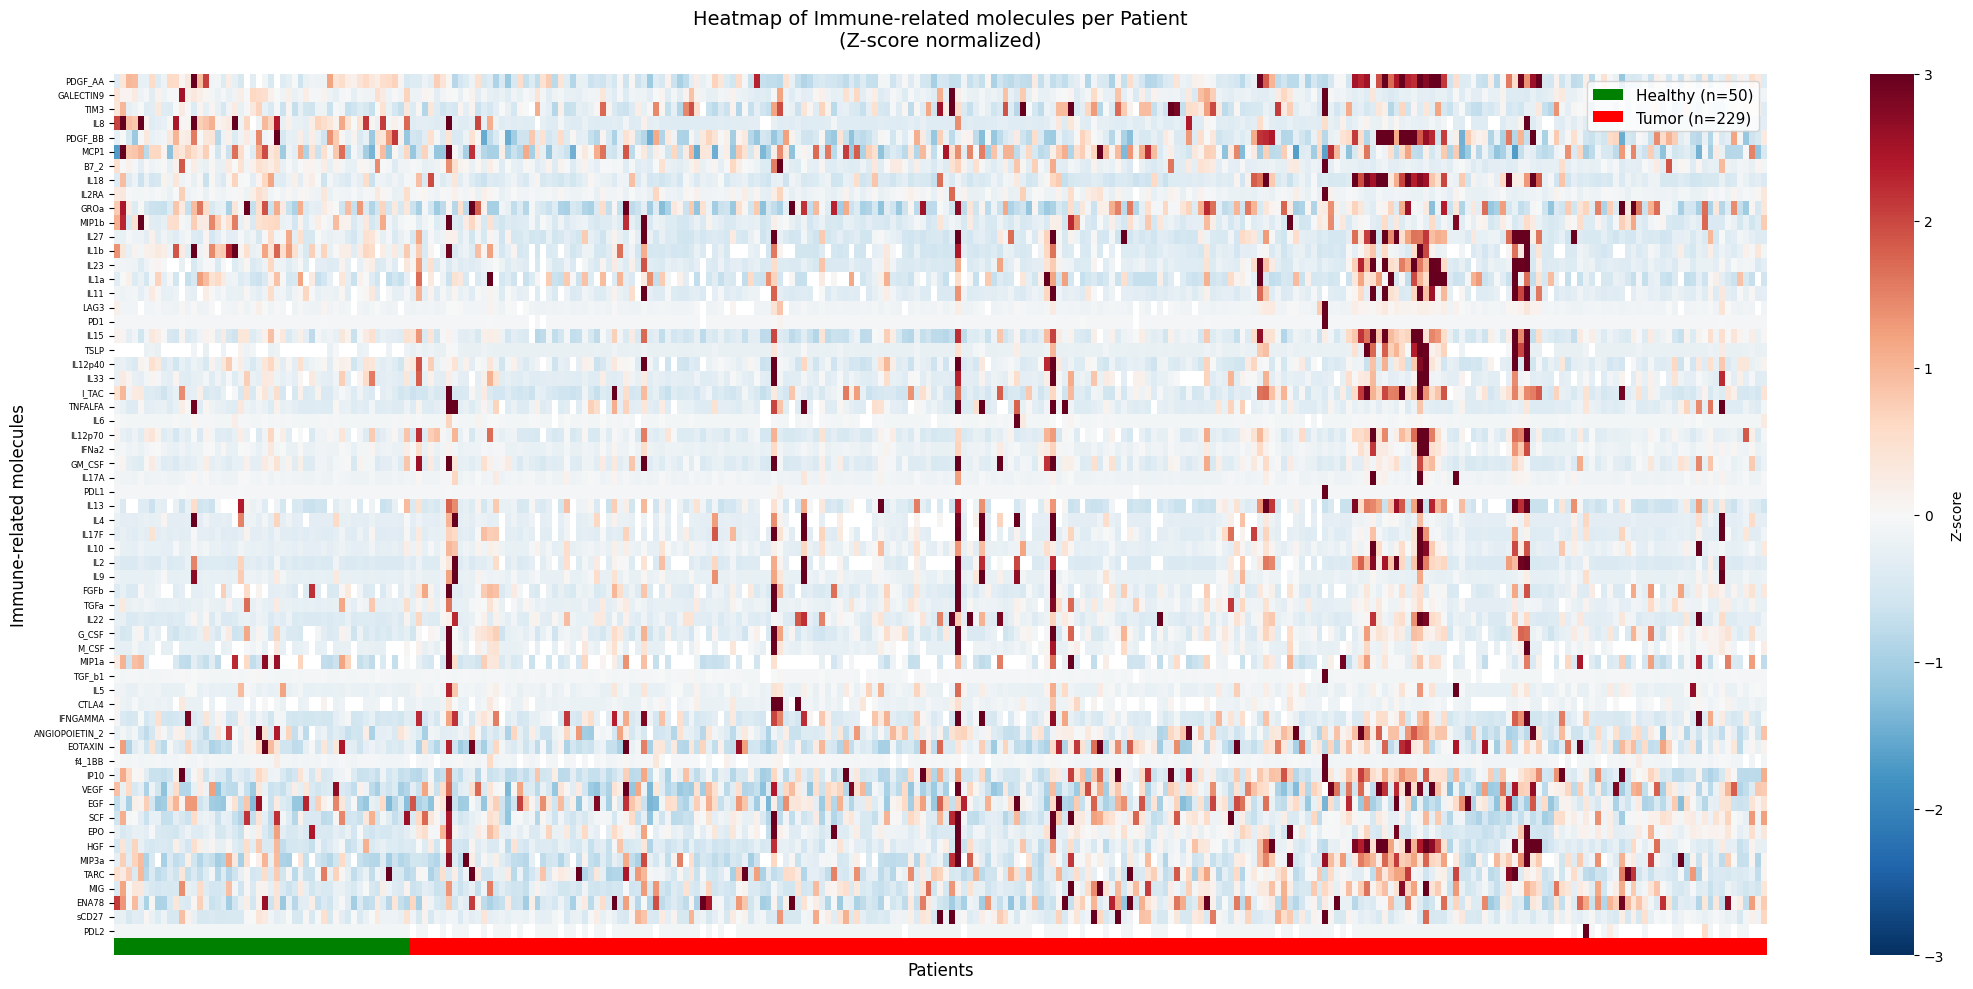

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# Preparar datos: separar genes y TvsS
genes_cols = [col for col in df.columns if col != 'TvsS']
X = df[genes_cols]
TvsS = df['TvsS']

# Crear versión normalizada (z-score)
scaler = StandardScaler()
X_normalized = pd.DataFrame(scaler.fit_transform(X), columns=genes_cols)

# Ordenar por TvsS (0 primero = sanos, luego 1 = tumores)
sort_idx = TvsS.argsort()
X_sorted = X.iloc[sort_idx].reset_index(drop=True)
X_norm_sorted = X_normalized.iloc[sort_idx].reset_index(drop=True)
TvsS_sorted = TvsS.iloc[sort_idx].values

# Crear índices para separación visual entre sanos y tumores
n_healthy = (TvsS_sorted == 0).sum()

# ===== Gene ordering by median difference Tumor-Healthy (used in both heatmaps) =====
gene_diff = (X[TvsS == 1].median() - X[TvsS == 0].median()).sort_values(ascending=False)
ordered_genes = gene_diff.index.tolist()
X_norm_reordered = X_norm_sorted[ordered_genes]

# ===== HEATMAP 1: Per patient - Z-score normalized expression =====
fig, ax = plt.subplots(figsize=(22, 10))

# Determine symmetric range for colorbar based on z-scores
# limit to typical z-score range for better contrast
v_range = 3

# Normalized (z-score) with standard RdBu_r palette and fixed limits
sns.heatmap(X_norm_reordered.T, cmap='RdBu_r', center=0, vmin=-v_range, vmax=v_range,
            cbar_kws={'label': 'Z-score'}, ax=ax, xticklabels=False, yticklabels=True, cbar=True)
# rotate gene labels and reduce font size for readability
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
# Add annotation bar on top showing Healthy/Tumor
bar_height = (X_norm_reordered.T.shape[0] * 0.02)  # 2% of heatmap height
bar_colors = ['green' if x == 0 else 'red' for x in TvsS_sorted]
for i, color in enumerate(bar_colors):
    ax.add_patch(plt.Rectangle((i, -bar_height), 1, bar_height, facecolor=color, edgecolor='none'))

# Set bottom margin to show the bar
ax.set_ylim(top=X_norm_reordered.T.shape[0], bottom=-bar_height)

# Add legend
legend_elements = [Patch(facecolor='green', label='Healthy (n={})'.format(n_healthy)),
                   Patch(facecolor='red', label='Tumor (n={})'.format(len(TvsS_sorted) - n_healthy))]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

ax.set_title('Heatmap of Immune-related molecules per Patient\n(Z-score normalized)', fontsize=14, pad=20)
ax.set_ylabel('Immune-related molecules', fontsize=12)
ax.set_xlabel('Patients', fontsize=12)

print(f"Heatmap 1 created: {n_healthy} healthy patients and {len(TvsS_sorted) - n_healthy} tumor patients")

plt.tight_layout()

plt.savefig('heatmap1_per_patient.png', dpi=300, bbox_inches='tight')
plt.show()

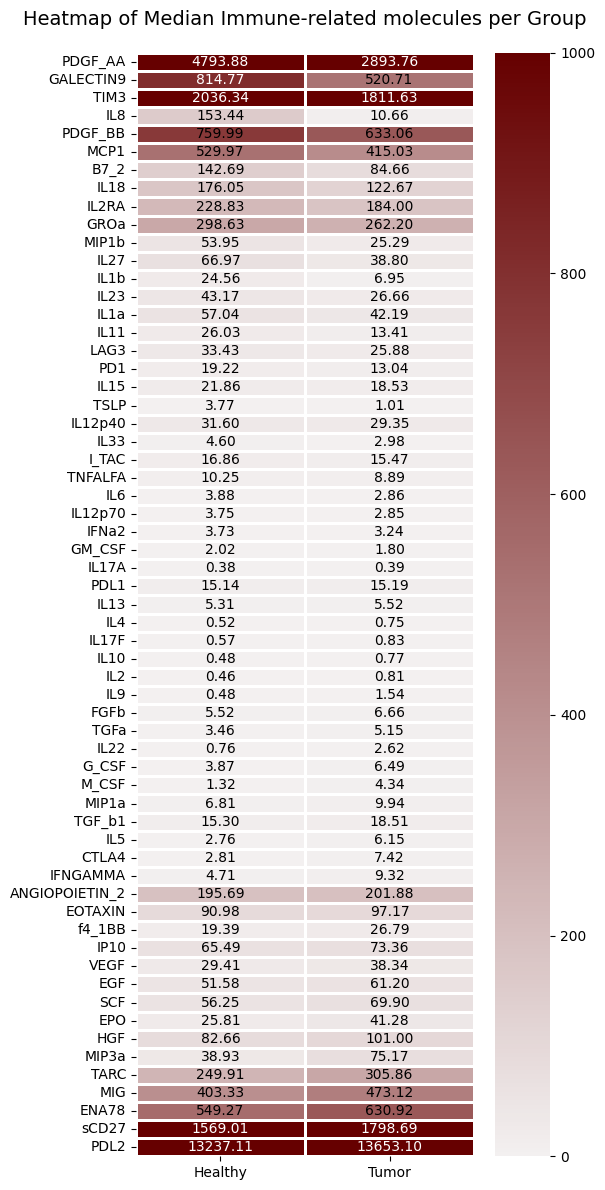

             Healthy      Tumor
PDGF_AA     4793.880   2893.760
GALECTIN9    814.770    520.710
TIM3        2036.335   1811.630
IL8          153.440     10.655
PDGF_BB      759.990    633.060
...              ...        ...
TARC         249.910    305.855
MIG          403.325    473.120
ENA78        549.275    630.920
sCD27       1569.005   1798.695
PDL2       13237.110  13653.100

[61 rows x 2 columns]
Heatmap 2 created - Median per group:


In [5]:
# ===== HEATMAP 2: Grouped by TvsS - Median expression (no normalization) =====

# Calculate median expression per group TvsS (no normalization)
mediana_por_grupo = pd.DataFrame({
    'Healthy': X[TvsS == 0].median(),
    'Tumor': X[TvsS == 1].median()
})

# Reorder genes by same criteria as Heatmap 1: median difference Tumor-Healthy
gene_diff = (X[TvsS == 1].median() - X[TvsS == 0].median()).sort_values(ascending=True)
ordered_genes = gene_diff.index.tolist()
mediana_por_grupo = mediana_por_grupo.loc[ordered_genes]

# Create heatmap with grey-to-red sequential palette and fixed range 0-3000
fig, ax = plt.subplots(figsize=(6, 12))
vmin = 0
vmax = 1000

# grey-red palette, light grey to dark red
cmap_gray_red = sns.color_palette("light:#660000", as_cmap=True)

heat = sns.heatmap(mediana_por_grupo, annot=True, fmt='.2f', cmap=cmap_gray_red, 
            vmin=vmin, vmax=vmax, cbar_kws={'label': ''}, 
            annot_kws={'color':'black'}, ax=ax, linewidths=1)

# change annotation color for very dark red cells
for txt in heat.texts:
    val = float(txt.get_text())
    if val > vmin + 0.8*(vmax - vmin):
        txt.set_color('white')

ax.set_title('Heatmap of Median Immune-related molecules per Group', fontsize=14, pad=20)
ax.set_ylabel('', fontsize=12)
ax.set_xlabel('', fontsize=12)

plt.tight_layout()
plt.savefig('heatmap2_median_per_group.png', dpi=300, bbox_inches='tight')
plt.show()

print(mediana_por_grupo)
print("Heatmap 2 created - Median per group:")